#### Loading dataset

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pylab as plt
import random

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

In [3]:
#Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

#### An overview of the images

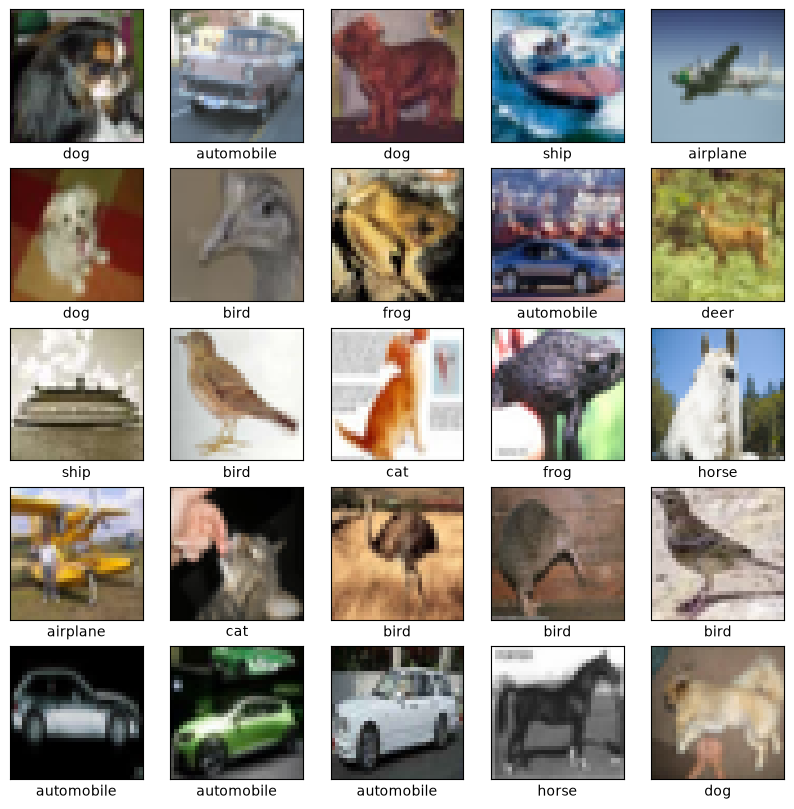

In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

train_idx = list(range(len(train_labels)))

random.seed(1)
random_sample = random.sample(train_idx, 25)

plt.figure(figsize=(10,10))
for i in range(len(random_sample)):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[random_sample[i]], cmap=plt.cm.binary)
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[random_sample[i]][0]])
plt.show()

#### Color channels

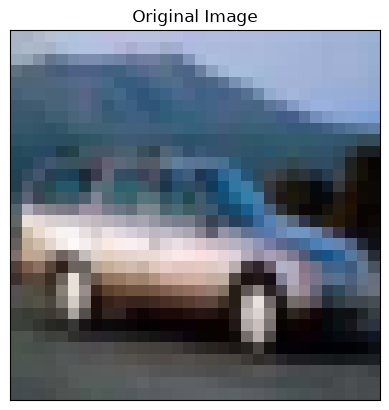

In [5]:
image_id = 4
plt.figure()
plt.imshow(train_images[image_id], cmap=plt.cm.binary)
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.title('Original Image')
plt.show()

This is an image of an automobile. Now we will split this color image into red, blue and green channels.

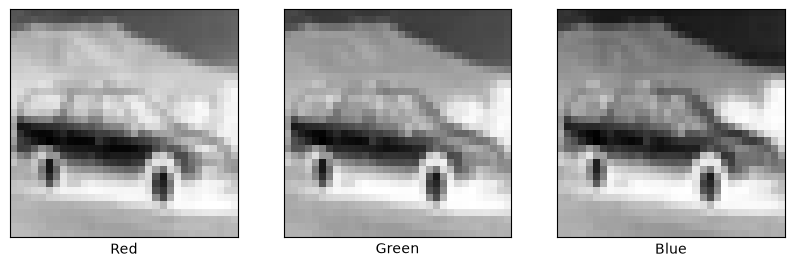

In [6]:
channel = ['Red', 'Green', 'Blue']
plt.figure(figsize=(10,10))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[image_id][:,:,i], cmap=plt.cm.binary)
    plt.xlabel(channel[i])
plt.show()

### Build, compile and train the model

In [7]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
validation_dataset = tf.data.Dataset.from_tensor_slices((test_images[:5000], test_labels[:5000]))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images[5000:], test_labels[5000:]))

TRAIN_DATASET_SIZE = len(train_dataset)
VALIDATION_DATASET_SIZE = len(validation_dataset)
TEST_DATASET_SIZE = len(test_dataset)

BATCH_SIZE = 128

train_dataset = train_dataset.shuffle(buffer_size=TRAIN_DATASET_SIZE).batch(BATCH_SIZE)
validation_dataset = validation_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

#building the model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10),
])

#compiling the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#training the model
model.fit(train_dataset, epochs=10, validation_data=validation_dataset)

_,accuracy = model.evaluate(test_dataset)
print(f"The model accuracy is: {accuracy*100:0.1f}%")

Epoch 1/10


/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/51.TutGator.com-Linkedin-TensorFlow-Working-with-Images/.venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/51.TutGator.com-Linkedin-TensorFlow-Working-with-Images/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3087 - loss: 1.9220 - val_accuracy: 0.3566 - val_loss: 1.7881
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3821 - loss: 1.7263 - val_accuracy: 0.3940 - val_loss: 1.7255
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4083 - loss: 1.6592 - val_accuracy: 0.4380 - val_loss: 1.6024
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4270 - loss: 1.6114 - val_accuracy: 0.4294 - val_loss: 1.6066
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4424 - loss: 1.5723 - val_accuracy: 0.4522 - val_loss: 1.5513
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4503 - loss: 1.5468 - val_accuracy: 0.4578 - val_loss: 1.5483
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4573 - loss: 1.5204 - val_accuracy: 0.4448 - val_loss: 1.5755
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4661 - loss: 1.5033 - val_accuracy: 0.4542 - val_

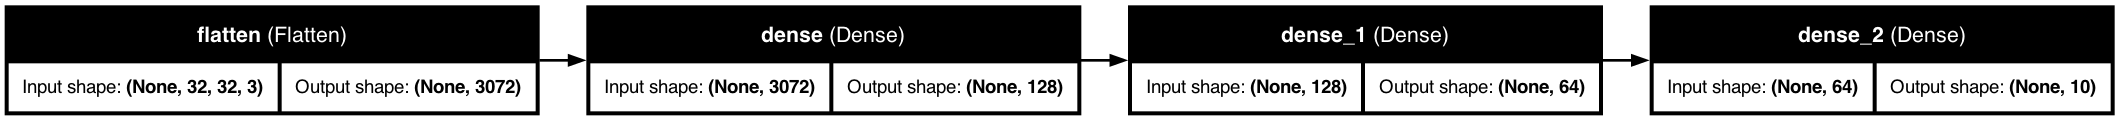

In [9]:
#CIFAR-10
tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True, rankdir ='LR', expand_nested=True, dpi=96)

### Make Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
ship


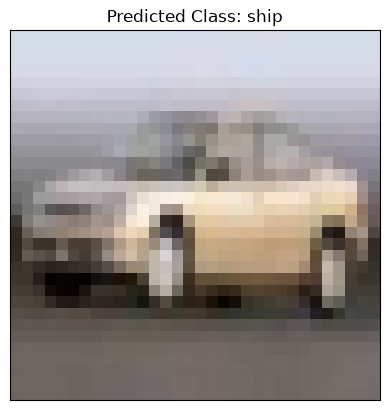

In [10]:
image_id = 7260 #pick an image id between 5000 and 9999 inclusive

def get_prediction(image_id):
    img = test_images[image_id]
    img = np.expand_dims(img, 0) # Create a batch
    pred = model.predict(img)
    pred = np.argmax(pred)
    print(class_names[pred])
    plt.figure()
    plt.imshow(test_images[image_id], cmap=plt.cm.binary)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('Predicted Class: ' + class_names[pred])
    plt.show()
get_prediction(image_id)

it is an image of an automobile and it is incorrectly classified as ship

#### More examples

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


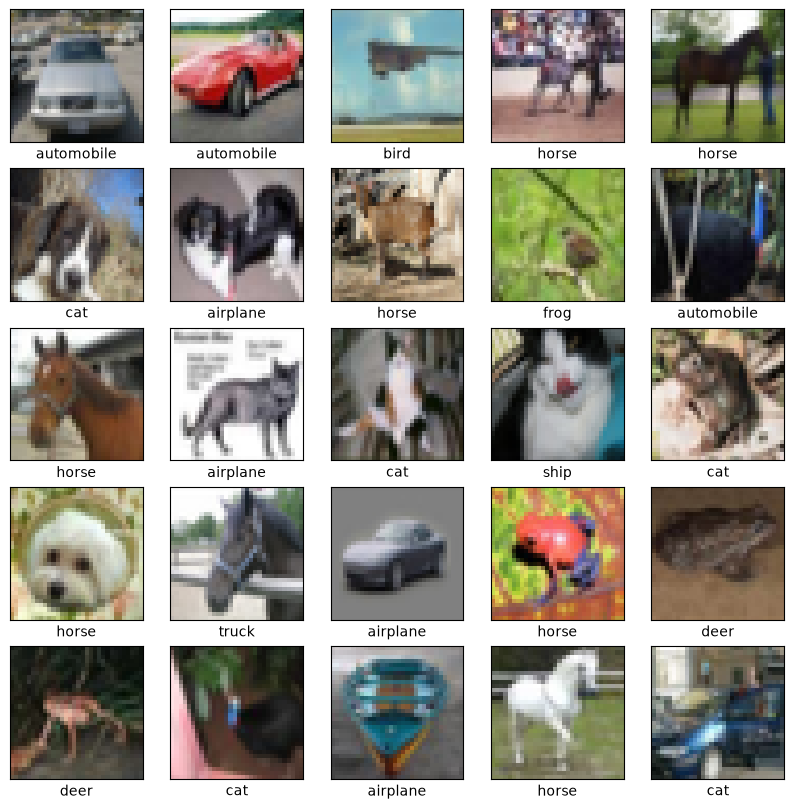

In [11]:
test_idx = list(range(5000, 10000))

random.seed(1)
random_sample = random.sample(test_idx, 25)

def get_pred_id(image_id):
    img = test_images[image_id]
    img = np.expand_dims(img, 0) # Create a batch
    pred = model.predict(img)
    pred = np.argmax(pred)
    return pred

pred_labels = [get_pred_id(i) for i in random_sample]

plt.figure(figsize=(10,10))
for i in range(len(random_sample)):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[random_sample[i]], cmap=plt.cm.binary)
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[pred_labels[i]])
plt.show()

Model accuracy is very low that's most images are not classified perfectly.

So, we can conclude that this neural network works pretty well for Fashion-Mnist dataset but not on this CIFAR-10 dataset.